In [1]:
import pandas as pd

synthetic_data = "data/synthetic/dataset.parquet"
df = pd.read_parquet(synthetic_data)

print(f"✅ Loaded {len(df)} rows from {synthetic_data}")
print("Columns:", list(df.columns))

✅ Loaded 540000 rows from data/synthetic/dataset.parquet
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'ret_log', 'corr_30', 'corr_60', 'ticker', 'ts', 'ts_min_max_norm', 'ts_low_high_norm', 'ts_first_minute_open', 'mask_ts', 'mask_ts_first_minute_open', 'ts_nan_count', 'ts_length', 'ts_min', 'ts_max', 'range', 'open_pos', 'close_pos', 'rel_volatility', 'mid_price', 'body_size', 'upper_shadow', 'lower_shadow', 'body_to_range', 'direction', 'volatility_ratio', 'index_open', 'index_high', 'index_low', 'index_close', 'index_ret_log', 'index_ts', 'index_ts_min_max_norm', 'index_ts_low_high_norm', 'index_ts_first_minute_open', 'index_mask_ts', 'index_mask_ts_first_minute_open', 'index_ts_nan_count', 'index_ts_length', 'index_ts_min', 'index_ts_max', 'index_range', 'index_open_pos', 'index_close_pos', 'index_rel_volatility', 'index_mid_price', 'index_body_size', 'index_upper_shadow', 'index_lower_shadow', 'index_body_to_range', 'index_direction', 'index_volatility_ratio']


In [2]:
import numpy as np

def check_mask_correctness(df):
    for i, (ts, mask) in enumerate(zip(df['index_ts'], df['index_mask_ts'])):
        ts = np.array(ts)
        mask = np.array(mask)

        if len(ts) != len(mask):
            print(f"Mismatch length at index {i}")
            return False

        invalid_mask = ((np.isnan(ts)) & (mask != 0)) | ((~np.isnan(ts)) & (mask != 1))
        if invalid_mask.any():
            print(f"Incorrect mask at index {i}")
            return False

    print("mask_ts is a valid mask for ts")
    return True

check_mask_correctness(df)

mask_ts is a valid mask for ts


True

In [3]:
def count_nans_per_column(df):
    nan_counts = df.isna().sum()
    return nan_counts[nan_counts > 0].sort_values(ascending=False)

In [4]:
count_nans_per_column(df)

corr_60          5400
corr_30          2700
ret_log            90
index_ret_log      90
dtype: int64

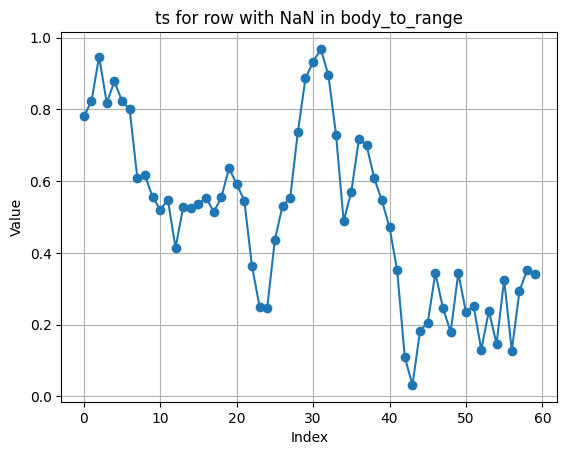

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# znajdź pierwszy wiersz z NaN w body_to_range
row = df[df['ret_log'].isna()].iloc[0]

# wyciągnij ts i rzuć na numpy
ts = np.array(row['ts_low_high_norm'])

# narysuj
plt.plot(ts, marker='o')
plt.title("ts for row with NaN in body_to_range")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()